In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv(os.path.join('data', 'Auto.csv'), na_values='?')
df


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [ ]:
# (a) remove missing values
df_new = df.dropna()
df_new

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
392,27.0,4,140.0,86.0,2790,15.6,82,1,ford mustang gl
393,44.0,4,97.0,52.0,2130,24.6,82,2,vw pickup
394,32.0,4,135.0,84.0,2295,11.6,82,1,dodge rampage
395,28.0,4,120.0,79.0,2625,18.6,82,1,ford ranger


In [28]:
quantitative_columns = ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration', ]
qualitative_columns = ['cylinders', 'year', 'origin']

# (b) finding the range of each quantitative column
for col in quantitative_columns:
    print('Range of {}: from {} to {}'.format(col, df_new[col].min(), df_new[col].max()))

Range of mpg: from 9.0 to 46.6
Range of displacement: from 68.0 to 455.0
Range of horsepower: from 46.0 to 230.0
Range of weight: from 1613 to 5140
Range of acceleration: from 8.0 to 24.8


In [17]:
# (c) finding the mean and standard deviation of each quantitative column
for col in quantitative_columns:
    print('Mean of {}: {:0.2f}'.format(col, df_new[col].mean()))
    print('Deviation of {}: {:0.2f}'.format(col, df_new[col].std()))

Mean of mpg: 23.45
Deviation of mpg: 7.81
Mean of displacement: 194.41
Deviation of displacement: 104.64
Mean of horsepower: 104.47
Deviation of horsepower: 38.49
Mean of weight: 2977.58
Deviation of weight: 849.40
Mean of acceleration: 15.54
Deviation of acceleration: 2.76
Mean of year: 75.98
Deviation of year: 3.68


In [19]:
# (d) remove the 10th through 85th observations
df_removed = df_new.drop(df_new.index[9:85])

In [20]:
for col in quantitative_columns:
    print('Range of {}: from {} to {}'.format(col, df_removed[col].min(), df_removed[col].max()))

Range of mpg: from 11.0 to 46.6
Range of displacement: from 68.0 to 455.0
Range of horsepower: from 46.0 to 230.0
Range of weight: from 1649 to 4997
Range of acceleration: from 8.5 to 24.8
Range of year: from 70 to 82


In [21]:
for col in quantitative_columns:
    print('Mean of {}: {:0.2f}'.format(col, df_removed[col].mean()))
    print('Deviation of {}: {:0.2f}'.format(col, df_removed[col].std()))

Mean of mpg: 24.40
Deviation of mpg: 7.87
Mean of displacement: 187.24
Deviation of displacement: 99.68
Mean of horsepower: 100.72
Deviation of horsepower: 35.71
Mean of weight: 2935.97
Deviation of weight: 811.30
Mean of acceleration: 15.73
Deviation of acceleration: 2.69
Mean of year: 77.15
Deviation of year: 3.11


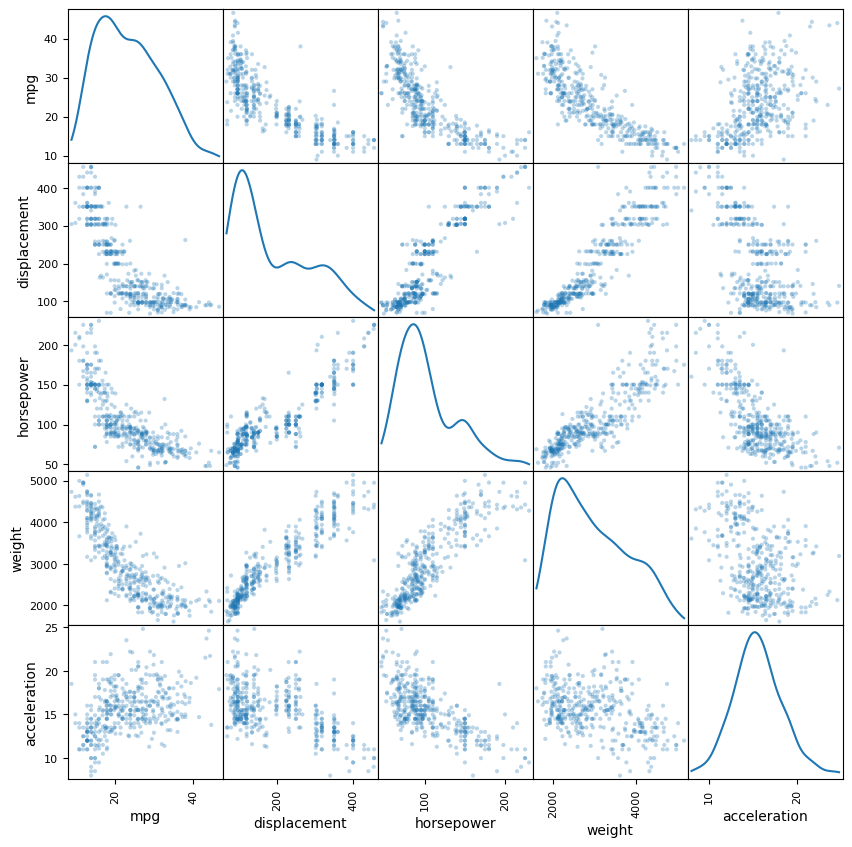

In [29]:
# (e) create a scatterplot matrix
pd.plotting.scatter_matrix(df_new.loc[:, quantitative_columns], alpha=0.3, figsize=(10, 10), diagonal='kde')
plt.show()

In [ ]:
# (f) compute the correlation matrix
correlation_matrix = df_new.loc[:, quantitative_columns].corr()
print(correlation_matrix)

# For predicting mpg, the most promising variables are displacement, weight, and horsepower, as they have the highest
# correlation with mpg. The variable acceleration has the lowest correlation with mpg. The variables displacement and
# weight are highly correlated with each other, which means that they may contain redundant information. The variable
# acceleration has a low correlation with the other variables, which means that it may contain unique information that
# is not captured by the other variables.


                   mpg  displacement  horsepower    weight  acceleration
mpg           1.000000     -0.805127   -0.778427 -0.832244      0.423329
displacement -0.805127      1.000000    0.897257  0.932994     -0.543800
horsepower   -0.778427      0.897257    1.000000  0.864538     -0.689196
weight       -0.832244      0.932994    0.864538  1.000000     -0.416839
acceleration  0.423329     -0.543800   -0.689196 -0.416839      1.000000
